# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [2]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [3]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "206300"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: ve4156f54
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,-0.016538,43.018893,0.521575,1.655328,1.497916,-1.904638,0.222300,1.437883,1.759158,0.065673,2.828626,-1.643311,1.425137
1,0.050956,2.105924,0.614250,0.583709,-0.222907,-2.561065,-0.204681,-0.761768,-0.897223,3.034937,2.189356,1.206762,13.335671
2,0.288236,29.047867,0.034066,1.103826,0.291142,-0.990111,-0.081187,-1.650323,-0.661312,1.431573,1.538132,-1.439328,11.813027
3,0.092715,85.235380,0.076054,2.503693,0.548479,-1.478452,0.200116,-0.189551,1.318149,0.163275,0.107913,-0.039166,4.256013
4,-0.290673,46.635657,1.699391,2.727966,-1.208724,-1.506360,-0.212527,-2.301914,0.371093,2.874299,1.719624,0.232811,8.193480


In [4]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,800.0,0.002420,0.280952,-0.498717,-0.239021,0.005941,0.240231,0.499955
x2,800.0,51.790027,28.853838,0.044404,26.128201,52.675401,77.134968,99.895466
x3,800.0,-0.045402,1.145991,-1.988778,-1.011680,-0.080588,0.919554,1.992305
x4,800.0,1.700165,2.085899,0.028052,0.550475,1.150945,2.111353,20.849548
x5,800.0,-0.043775,1.047102,-4.239656,-0.696942,-0.034661,0.645067,3.755136
x6,800.0,-0.103522,1.697917,-2.988159,-1.516020,-0.124527,1.260174,2.999545
x7,800.0,-0.022830,0.288071,-0.499957,-0.269693,-0.038929,0.219460,0.499472
x8,800.0,0.021585,1.779906,-2.998694,-1.613401,0.011730,1.658716,2.993659
x9,800.0,-0.037215,0.994205,-3.173426,-0.690699,-0.069902,0.638655,2.739714
x10,800.0,1.712386,3.119408,0.052481,0.495481,0.978351,1.935506,58.315763


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 103.04
R² del baseline en validación : 0.446

Desviación estándar de y: 13.79


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x2'}>,
        <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x5'}>,
        <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x8'}>,
        <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x11'}>,
        <Axes: title={'center': 'x12'}>]], dtype=object)

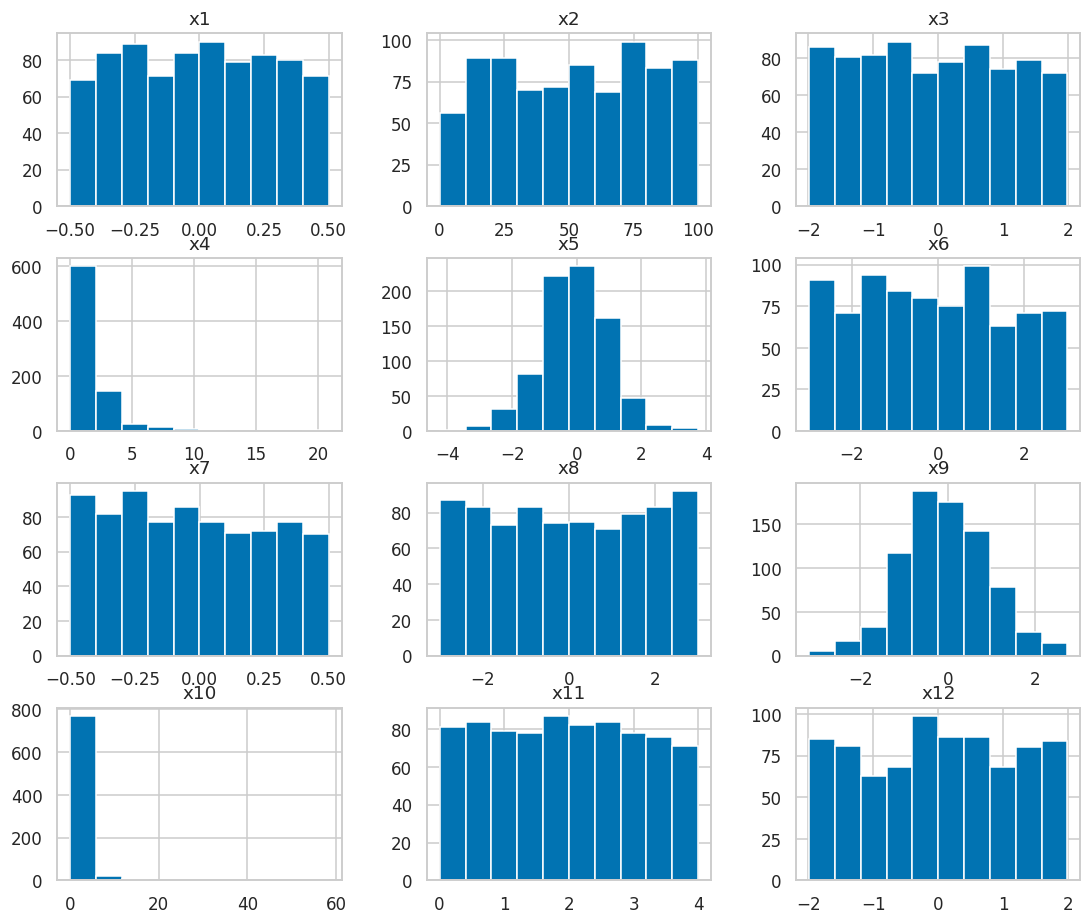

In [6]:
# TODO: distribución de cada una de las 12 variables.
train[VARIABLES].hist(figsize=(12, 10))

MIS OBSERVACIONES:

x4 y x10 son positivas y presentan fuerte asimetría hacia la derecha

x5 y x9 parecen aproximadamente simétricas y con forma de campana

varias de las demás (x1, x2, x3, x6, x7, x8, x11, x12) se ven más planas o sin una concentración central tan marcada.

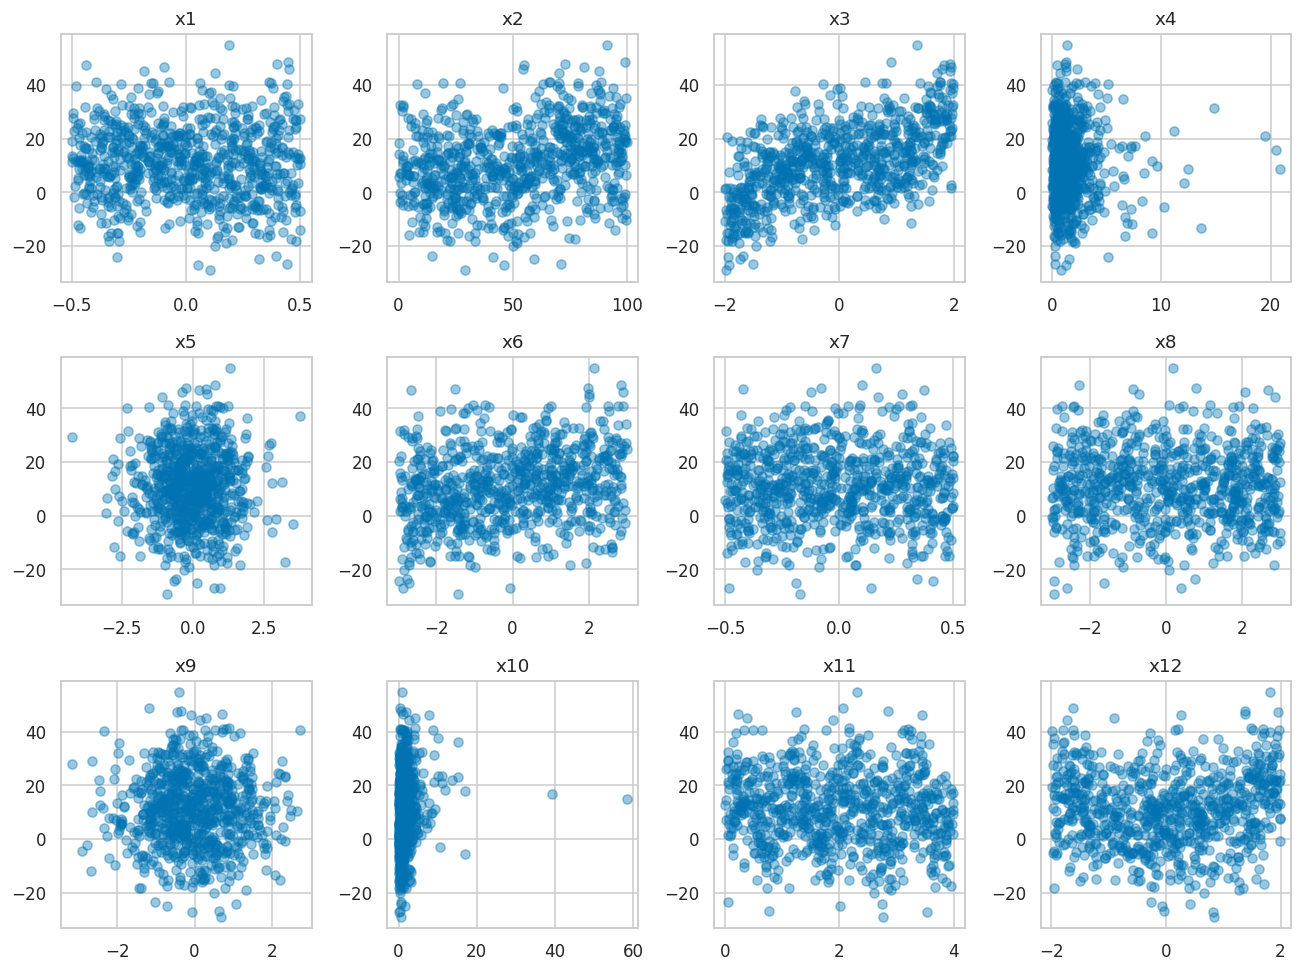

In [7]:
# TODO: "y" contra cada variable. Una rejilla de 12 paneles.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for x, ax in zip(VARIABLES, axes.flat):
    ax.scatter(train[x], train["y"], alpha=0.4)
    ax.set_title(x)

plt.tight_layout()
plt.show()

MIS OBSERVACIONES:

x1, x2, x6, x7, x8 y x11: presentan una nube de puntos bastante dispersa (No identifico una relación clara, lineal o no lineal, con y)

x3: muestra una tendencia positiva aproximadamente lineal. Conforme x3 aumenta, y tiende a aumentar.

x4 y x10: la mayoría de los puntos se concentra cerca de valores bajos de x (nube casi vertical) 

x5 y x9: los puntos forman una nube concentrada alrededor del centro.

x12: muestra una posible relación no lineal en forma de U con y. Inicialmente parece existir una relación negativa que después se vuelve positiva

In [8]:
# TODO: matriz de correlación entre las 12 variables y "y"

corr = train.corr()
corr

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
x1,1.000000,-0.043674,-0.041350,-0.042284,-0.017274,0.016699,0.023683,0.029059,-0.093086,-0.038268,0.070032,-0.037960,-0.047344
x2,-0.043674,1.000000,0.027500,-0.051762,-0.012618,0.084708,-0.043953,0.022533,0.025435,0.023192,-0.046928,0.056681,0.267208
x3,-0.041350,0.027500,1.000000,-0.000573,0.026516,-0.000622,0.005471,0.002789,-0.026757,-0.001643,-0.043396,0.005857,0.555884
x4,-0.042284,-0.051762,-0.000573,1.000000,-0.034328,-0.050633,0.007823,0.023394,0.003108,0.014379,0.083047,-0.036870,-0.025099
x5,-0.017274,-0.012618,0.026516,-0.034328,1.000000,-0.011329,-0.062221,0.031263,0.048667,0.031730,0.059374,0.011938,0.003256
x6,0.016699,0.084708,-0.000622,-0.050633,-0.011329,1.000000,-0.017300,-0.071826,0.022622,0.023005,0.027829,0.078820,0.241777
x7,0.023683,-0.043953,0.005471,0.007823,-0.062221,-0.017300,1.000000,-0.020593,0.035106,0.024692,0.007834,-0.014806,-0.005608
x8,0.029059,0.022533,0.002789,0.023394,0.031263,-0.071826,-0.020593,1.000000,-0.038180,0.066404,-0.043420,-0.053203,-0.004244
x9,-0.093086,0.025435,-0.026757,0.003108,0.048667,0.022622,0.035106,-0.038180,1.000000,0.036190,-0.023522,0.035474,-0.008072
x10,-0.038268,0.023192,-0.001643,0.014379,0.031730,0.023005,0.024692,0.066404,0.036190,1.000000,-0.013576,-0.042889,0.117353


MIS OBSERVACIONES:

x3 presenta la mayor correlación lineal positiva con y. x2 y x6 también muestran correlaciones positivas, aunque más moderadas. x10 presenta una correlación positiva débil.

x1, x4, x5, x7, x8 y x9 tienen correlaciones muy cercanas a cero, por lo que no muestran una relación lineal clara con y. 

x11 presenta una correlación negativa débil.

Finalmente, x12 tiene una correlación lineal baja, pero en la gráfica anterior observé una relación en forma de U. Por lo tanto, creo que podría existir una relación no lineal, posiblemente cuadrática

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | | | |
| `x2` | | | |
| `x3` | | | |
| `x4` | | | |
| `x5` | | | |
| `x6` | | | |
| `x7` | | | |
| `x8` | | | |
| `x9` | | | |
| `x10` | | | |
| `x11` | | | |
| `x12` | | | |

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [9]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 103.04


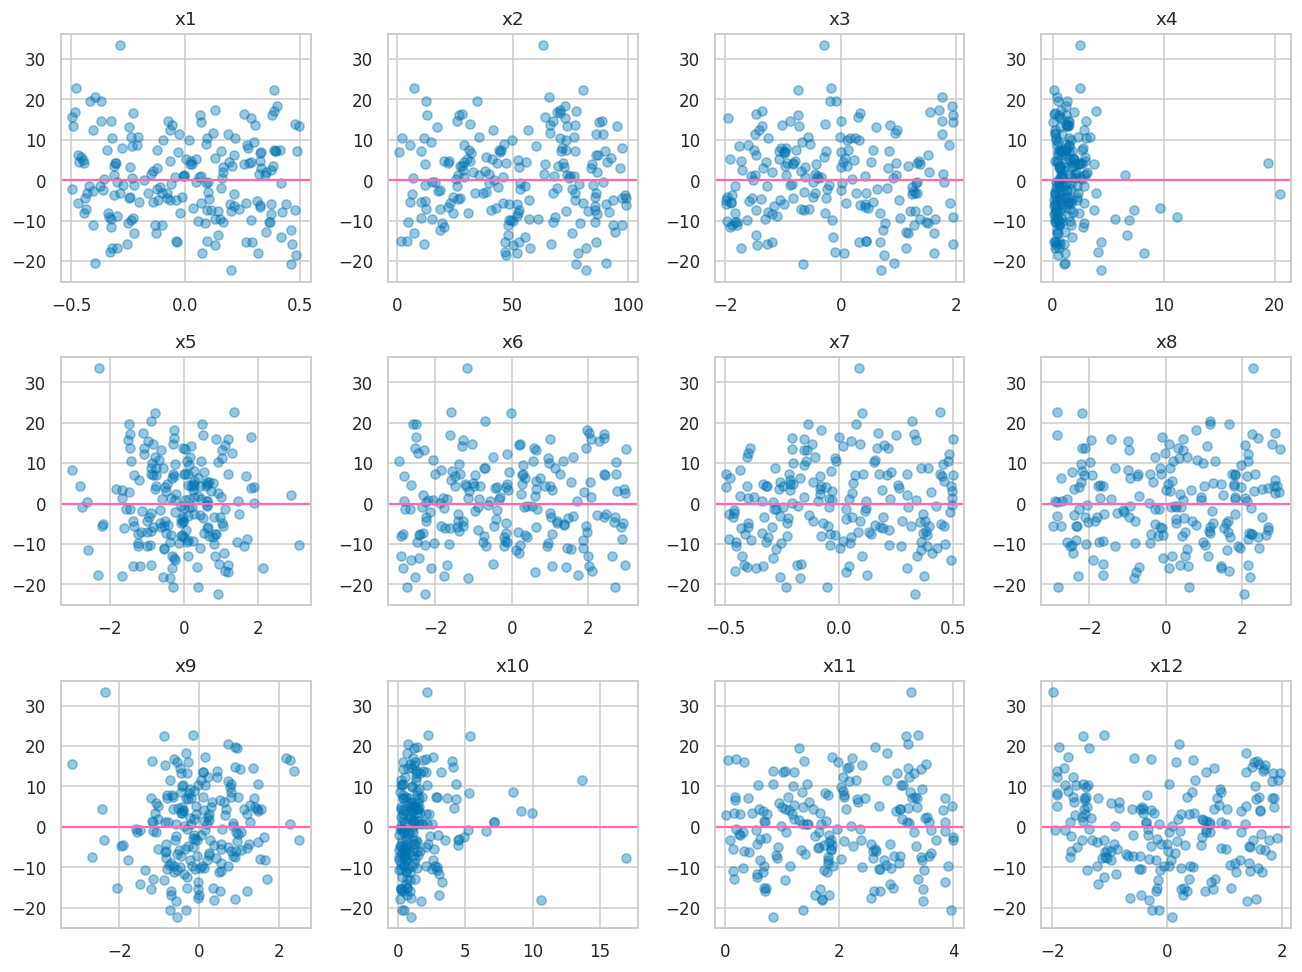

In [10]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for x, ax in zip(VARIABLES, axes.flat):
    ax.scatter(X_val[x], residuales, alpha=0.4)
    ax.axhline(0, color="hotpink")
    ax.set_title(x)

plt.tight_layout()
plt.show()

Hipótesis 1: 

En la gráfica de residuales de x12 observo una forma de U: los residuales disminuyen y después vuelven a aumentar. Esto sugiere que el modelo lineal no captura por completo el efecto de x12. Por esta razón, considero que podría existir una relación cuadrática y propongo agregar el término x12².

In [11]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a "ajusta". El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.

modelo, mse, residuales, _ = ajusta({
    "x12_cuadrada": lambda d: d["x12"] ** 2
})

print(f"MSE: {mse:.2f}")

MSE: 87.17


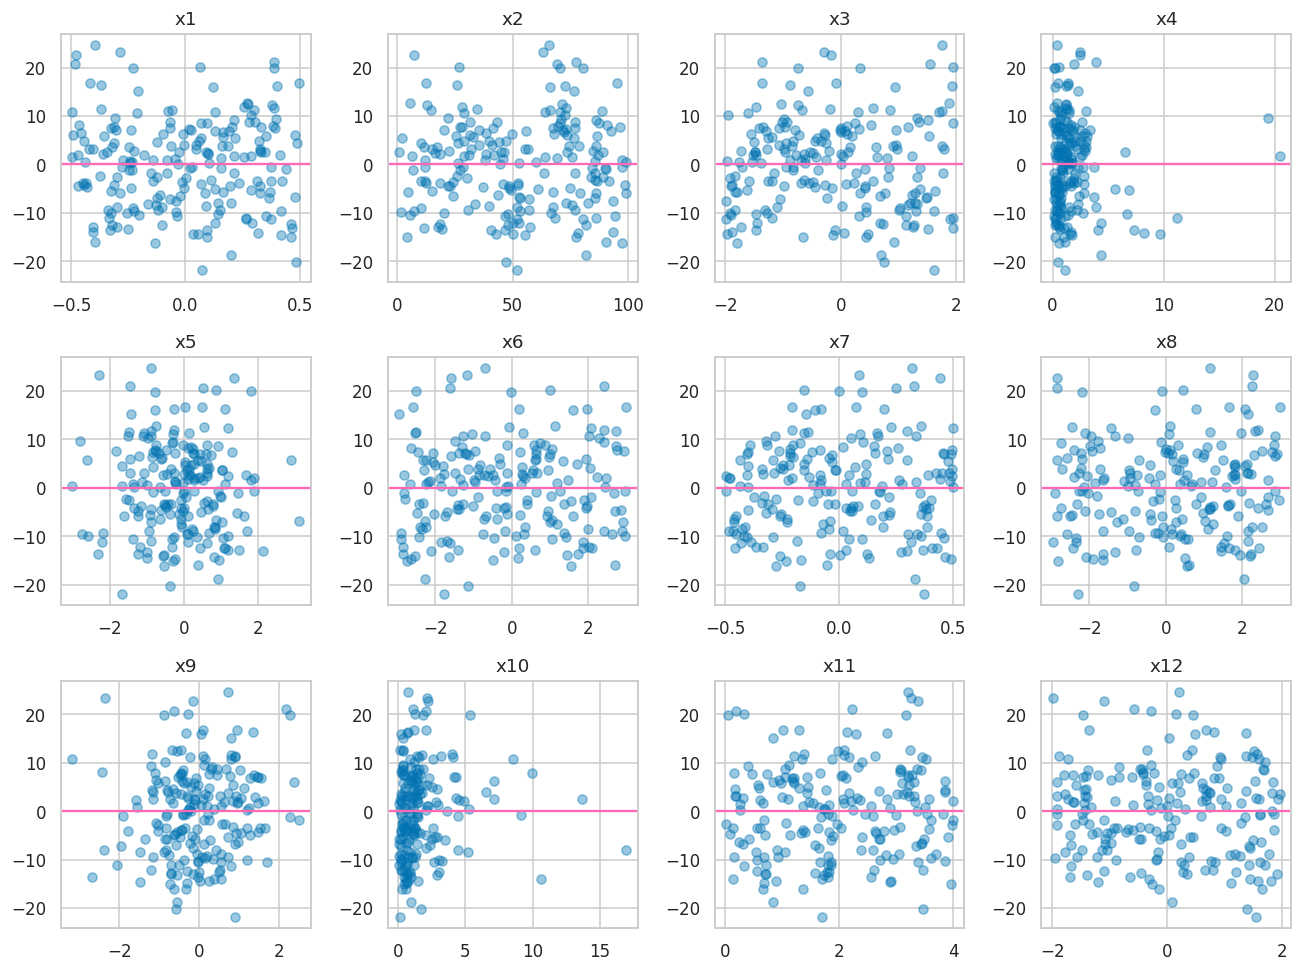

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for x, ax in zip(VARIABLES, axes.flat):
    ax.scatter(X_val[x], residuales, alpha=0.4)
    ax.axhline(0, color="hotpink")
    ax.set_title(x)

plt.tight_layout()
plt.show()

Resultado 1 [gran cambio]: 

Al agregar x12², el MSE de validación disminuyó de 103.04 a 87.17. Además, al volver a graficar los residuales, la forma de U de x12 prácticamente desapareció. Esto indica que el término cuadrático captura parte de la estructura que el modelo lineal no explicaba.

Hipótesis 2: 

En la gráfica de residuales de x1 observo una forma parecida a una V. Esto sugiere que el efecto de x1 podría no ser lineal y que un término de valor absoluto, |x1|, podría capturar mejor esa relación.

In [13]:
modelo, mse, residuales, _ = ajusta({
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_absoluta": lambda d: abs(d["x1"])
})

print(f"MSE: {mse:.2f}")

MSE: 87.03


Resultado 2 [mejora mínima]: 

Al agregar |x1| al modelo que ya incluía x12², el MSE disminuyó de 87.17 a 87.03. La mejora fue mínima, por lo que el valor absoluto de x1 no parece aportar una mejora importante al modelo.

Hipótesis 3: 

En la gráfica de residuales de x2 observo una forma parecida a < (similar a x1), con un cambio en la dirección de los residuales. Esto sugiere que la relación podría no ser completamente lineal. Propongo agregar un término de valor absoluto, |x2|, para evaluar si captura esta estructura.

In [14]:
modelo, mse, residuales, _ = ajusta({
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x2_absoluta": lambda d: abs(d["x2"])
})

print(f"MSE: {mse:.2f}")

MSE: 87.17


Resultado 3 [sin mejora]: 

Al agregar |x2| al modelo que ya contenía x12², el MSE se mantuvo en 87.17. Por lo tanto, esta transformación no mejoró el modelo y decidí descartarla.

Hipótesis 4: 

En la gráfica de residuales de x6 observo una forma parecida a una V invertida. Esto sugiere que el efecto de x6 podría cambiar de dirección alrededor de un punto central. Propongo agregar el término -|x6| para evaluar si captura mejor esta estructura.

In [15]:
modelo, mse, residuales, _ = ajusta({
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x6_abs_invertida": lambda d: -abs(d["x6"])
})

print(f"MSE: {mse:.2f}")

MSE: 86.74


Resultado 4: 

Al agregar -|x6| al modelo que ya incluía x12², el MSE disminuyó de 87.17 a 86.74. La mejora fue pequeña, pero positiva, por lo que este término podría aportar información adicional. Conviene conservarlo de forma provisional y verificar más adelante con validación cruzada si la mejora se mantiene.

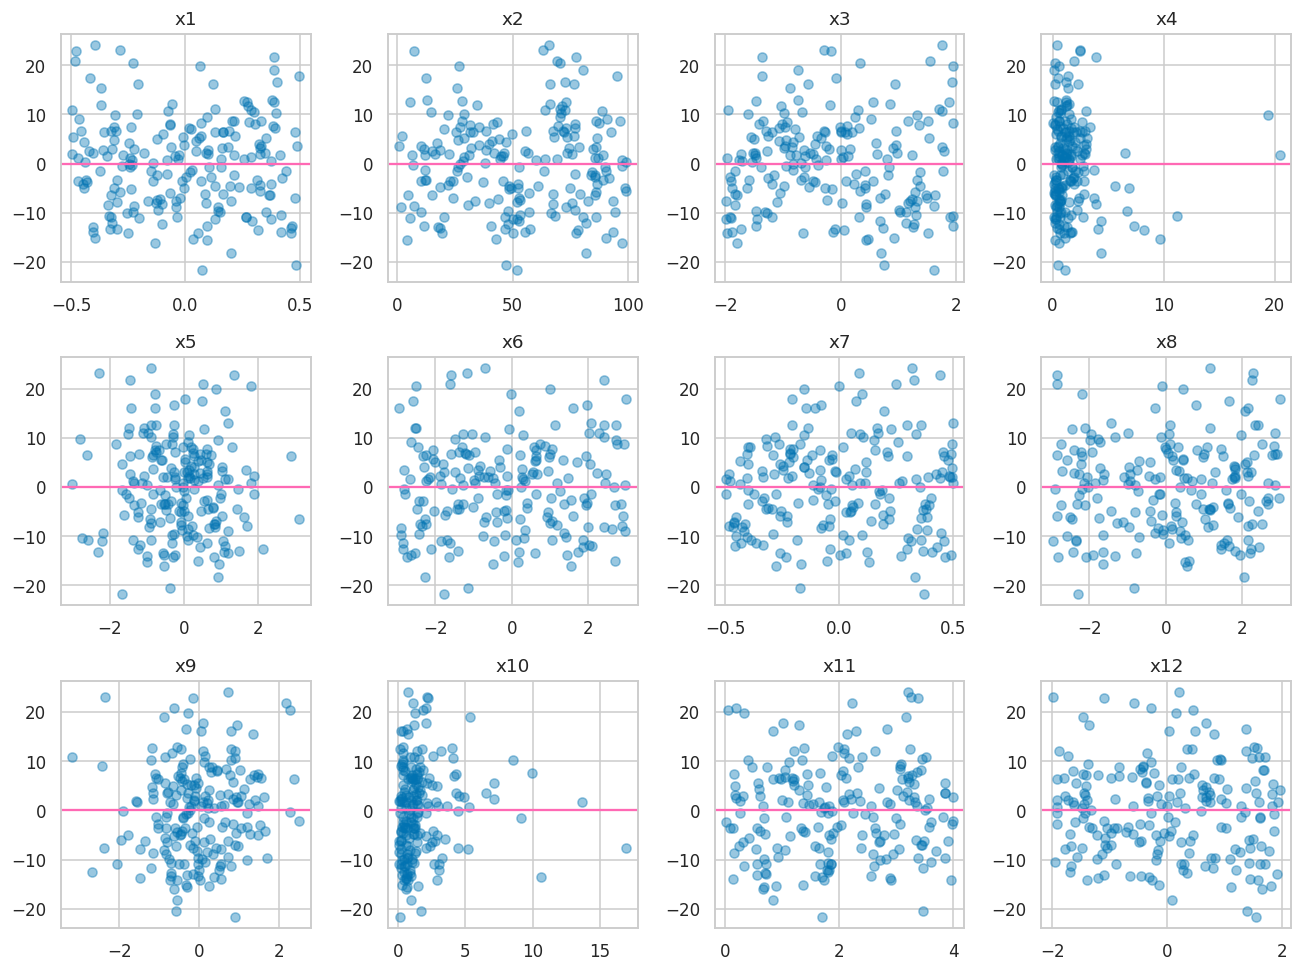

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for x, ax in zip(VARIABLES, axes.flat):
    ax.scatter(X_val[x], residuales, alpha=0.4)
    ax.axhline(0, color="hotpink")
    ax.set_title(x)

plt.tight_layout()
plt.show()

Hipótesis 5: 

En la gráfica de residuales de x7 observo una forma parecida a una V. Esto sugiere que podría existir una relación no lineal que cambia de dirección alrededor de un punto central. Propongo agregar el término |x7| para evaluar si captura esta estructura.

In [17]:
modelo, mse, residuales, _ = ajusta({
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x6_abs_invertida": lambda d: -abs(d["x6"]),
    "x7_absoluta": lambda d: abs(d["x7"])
})

print(f"MSE: {mse:.2f}")

MSE: 85.64


Resultado 5: 

Al agregar |x7| al modelo que ya incluía x12² y -|x6|, el MSE disminuyó de 86.74 a 85.64. La mejora fue mayor que la obtenida con la transformación anterior, por lo que decidí conservar |x7| provisionalmente.

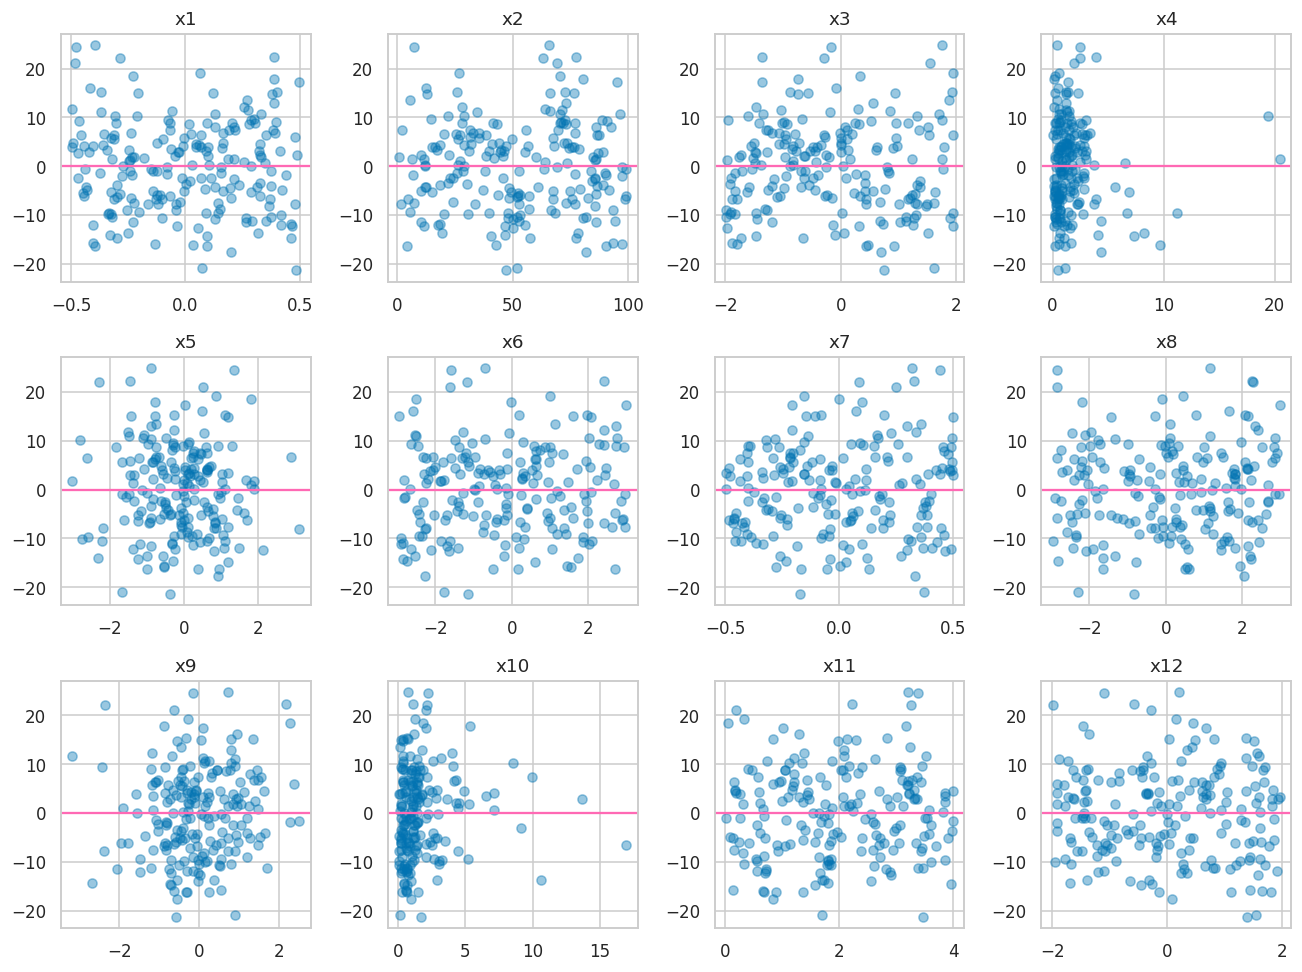

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for x, ax in zip(VARIABLES, axes.flat):
    ax.scatter(X_val[x], residuales, alpha=0.4)
    ax.axhline(0, color="hotpink")
    ax.set_title(x)

plt.tight_layout()
plt.show()

Hipótesis 6: 

En la gráfica de residuales de x11 observo una forma parecida a una V invertida (similar a x6). Esto sugiere que podría existir una relación no lineal que cambia de dirección. Por esta razón, propongo probar el término -|x11|

In [19]:
modelo, mse, residuales, _ = ajusta({
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x6_abs_invertida": lambda d: -abs(d["x6"]),
    "x7_absoluta": lambda d: abs(d["x7"]),
    "x11_abs_invertida": lambda d: -abs(d["x11"])
})

print(f"MSE: {mse:.2f}")

MSE: 85.64


Resultado 6: 

Al agregar -|x11| al modelo, el MSE se mantuvo en 85.64. La transformación no produjo una mejora, por lo que decidí descartarla.

MI OBSERVACIÓN:

En x3 los residuales muestran cierta irregularidad o posible patrón ondulado, aunque no se aprecia una forma suficientemente clara como para justificar una transformación específica por ahora.

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [ ]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.

Hipótesis 7: 

En los residuales de x3 observé un patrón irregular que no parece explicarse completamente con una transformación de una sola variable. Esto sugiere que el efecto de x3 podría depender del valor de otra variable, es decir, que podría existir una interacción. Por esta razón, propongo explorar productos entre x3 y las demás variables para identificar si alguna interacción reduce de forma clara el MSE.

In [21]:
for x in VARIABLES:
    if x != "x3":
        modelo_temp, mse_temp, _, _ = ajusta({
            "x12_cuadrada": lambda d: d["x12"] ** 2,
            "x6_abs_invertida": lambda d: -abs(d["x6"]),
            "x7_absoluta": lambda d: abs(d["x7"]),
            "interaccion": lambda d, x=x: d["x3"] * d[x]
        })
        
        print(f"x3 * {x}: MSE = {mse_temp:.2f}")

x3 * x1: MSE = 85.86
x3 * x2: MSE = 85.58
x3 * x4: MSE = 86.03
x3 * x5: MSE = 85.87
x3 * x6: MSE = 85.46
x3 * x7: MSE = 86.48
x3 * x8: MSE = 85.82
x3 * x9: MSE = 85.75
x3 * x10: MSE = 85.39
x3 * x11: MSE = 85.64
x3 * x12: MSE = 85.68


Resultado 7: 

Ninguna interacción produjo una reducción importante del MSE respecto al modelo actual de 85.64. La mejor fue x3*x10, con un MSE de 85.39, una mejora pequeña. Por lo tanto, no encontré evidencia suficiente para incorporar una interacción con x3 al modelo.

Hipótesis 8: 

En los residuales de x11 observé un patrón que no logré capturar mediante una transformación individual, ya que -|x11| no redujo el MSE. Esto sugiere que el efecto de x11 podría depender de otra variable. Por esta razón, propongo explorar interacciones entre x11 y las demás variables para determinar si alguna reduce de forma clara el MSE.

In [ ]:
for x in VARIABLES:
    if x != "x11":
        modelo_temp, mse_temp, _, _ = ajusta({
            "x12_cuadrada": lambda d: d["x12"] ** 2,
            "x6_abs_invertida": lambda d: -abs(d["x6"]),
            "x7_absoluta": lambda d: abs(d["x7"]),
            "interaccion": lambda d, x=x: d["x11"] * d[x]
        })
        
        print(f"x11 * {x}: MSE = {mse_temp:.2f}")

x11 * x1: MSE = 86.36
x11 * x2: MSE = 85.94
x11 * x3: MSE = 85.64
x11 * x4: MSE = 85.84
x11 * x5: MSE = 86.28
x11 * x6: MSE = 86.05
x11 * x7: MSE = 88.74
x11 * x8: MSE = 85.49
x11 * x9: MSE = 85.10
x11 * x10: MSE = 85.27
x11 * x12: MSE = 85.50


Resultado - Exploración de interacciones: 

Después de observar patrones residuales que no se explicaban mediante transformaciones individuales, exploré interacciones entre pares de variables mediante productos. Primero revisé interacciones de x3 y x11 con las demás variables y posteriormente probé los 66 pares posibles. Ninguna interacción redujo de forma importante el MSE respecto al modelo actual de 85.64. Por lo tanto, concluí que las interacciones lineales simples entre pares de variables no aportan una mejora sustancial al modelo.

---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [36]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.

from sklearn.pipeline import make_pipeline

fuerza_bruta = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LassoCV(cv=5, max_iter=20000)
)

fuerza_bruta.fit(X_train, y_train)

pred_fb = fuerza_bruta.predict(X_val)

mse_fb = mean_squared_error(y_val, pred_fb)

lasso = fuerza_bruta.named_steps["lassocv"]
columnas_no_cero = np.count_nonzero(lasso.coef_)

print(f"MSE fuerza bruta: {mse_fb:.2f}")
print(f"Columnas distintas de cero: {columnas_no_cero}")

MSE fuerza bruta: 53.33
Columnas distintas de cero: 22


Resultado de fuerza bruta: 

El modelo con PolynomialFeatures(degree=3), estandarización y LassoCV obtuvo un MSE de validación de 53.33 y conservó 22 columnas con coeficientes distintos de cero. Este resultado mejora de forma considerable el MSE de 85.64 obtenido con el modelo guiado por gráficas. Por lo tanto, la fuerza bruta logró capturar estructuras que no identifiqué mediante el análisis individual de los residuales.

### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

*(Su respuesta aquí)*

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

*(Su respuesta aquí)*

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(Su respuesta aquí)*

1. El modelo de fuerza bruta obtuvo el menor MSE de validación, con 53.33, en comparación con 85.64 del modelo guiado por gráficas. Por lo tanto, el modelo de fuerza bruta tuvo un mejor desempeño en el conjunto de validación.

2. No aplica

3. El mejor desempeño de la fuerza bruta indica que a nuestro modelo manual todavía le faltan términos relevantes. Nosotros probamos pocas interacciones y transformaciones a partir de los patrones observados en las gráficas, mientras que la fuerza bruta generó automáticamente una gran cantidad de potencias e interacciones hasta grado 3. Esto permitió seleccionar relaciones que no eran tan evidentes visualmente.

4. Con solo 80 observaciones habría un mayor riesgo de overfitting, porque el modelo tendría cientos de términos candidatos y muy pocos datos para determinar cuáles representan relaciones reales. Podría ajustarse demasiado a las particularidades de esas 80 observaciones y obtener un buen desempeño en entrenamiento, pero peor capacidad para generalizar a datos nuevos. 

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [37]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    # No lo utilizaré porque la fuerza bruta le ganó a mi modelo
}

def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


modelo_final = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LassoCV(cv=5, max_iter=20000)
)

modelo_final.fit(train[VARIABLES], train["y"])

predicciones = modelo_final.predict(test[VARIABLES])

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")


Escrito: entregas/tarea-01/ve4156f54/predicciones.csv
400 predicciones, rango -21.93 a 41.49


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.